# 02 - Fine-Tuning IndoT5 dengan Grid Search Hyperparameter

Total eksperimen: **1 baseline + 18 grid search = 19 run**

| # | Konfigurasi | Epoch | Batch Size | Learning Rate |
|---|---|---|---|---|
| 0 | **Baseline** (default, tanpa tuning) | - | - | - |
| 1–18 | **Grid Search** | 5, 10, 15 | 4, 8 | 1e-4, 3e-5, 5e-5 |

> Setiap run dievaluasi dengan ROUGE pada `test.csv`. Model dengan ROUGE-L tertinggi disimpan sebagai model final.

In [1]:
from huggingface_hub import login
from google.colab import userdata
import os

try:
    # Ambil token "HF_TOKEN" langsung dari Secret Colab
    my_token = userdata.get('HF_TOKEN')

    if my_token:
        # Login menggunakan token
        login(token=my_token, add_to_git_credential=True)
        print("Berhasil login ke Hugging Face menggunakan Secret Colab!")
    else:
        print("Token HF_TOKEN tidak ditemukan di Secrets Colab.")

except Exception as e:
    print(f"Gagal mengambil secret: {e}")

Berhasil login ke Hugging Face menggunakan Secret Colab!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers datasets evaluate sentencepiece accelerate rouge-score -q

import shutil

# ======================================================
# folder tempat data latih csv
DRIVE_DATA_DIR = '/content/drive/MyDrive/data_latih'
# ======================================================

shutil.copy(f'{DRIVE_DATA_DIR}/train.csv', 'train.csv')
shutil.copy(f'{DRIVE_DATA_DIR}/test.csv',  'test.csv')
print("Data berhasil di-copy dari Google Drive!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data berhasil di-copy dari Google Drive!


## 3. Import & Konfigurasi

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset
import pandas as pd
import evaluate
import torch
import shutil
import itertools
from pathlib import Path

MODEL_NAME = "Wikidepia/IndoT5-base"
DATA_DIR    = Path('.')
OUTPUT_ROOT = Path('/content/drive/MyDrive/models')
BEST_DIR    = OUTPUT_ROOT / 'indot5_finetuned'
LOG_DIR     = OUTPUT_ROOT / 'training_logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

PREFIX  = 'ringkas: '
MAX_IN  = 512
MAX_OUT = 150

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_NAME}')

Device : cuda
Model  : Wikidepia/IndoT5-base


## 4. Data Loading & Tokenization

In [ ]:
df_train = pd.read_csv('train.csv')
df_test  = pd.read_csv('test.csv')
print(f'Train: {len(df_train)} | Test: {len(df_test)}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenisasi(examples):
    inputs = [PREFIX + str(s) for s in examples['input_whisper_segment']]
    m_in   = tokenizer(inputs, max_length=MAX_IN, truncation=True, padding='max_length')
    
    labels = tokenizer(
        text_target=[str(t) for t in examples['target_summary_manual']],
        max_length=MAX_OUT, truncation=True, padding='max_length'
    )
    
    m_in['labels'] = [
        [-100 if t == tokenizer.pad_token_id else t for t in seq]
        for seq in labels['input_ids']
    ]
    return m_in

train_ds = Dataset.from_pandas(df_train).map(tokenisasi, batched=True, remove_columns=df_train.columns.tolist())
test_ds  = Dataset.from_pandas(df_test).map(tokenisasi, batched=True, remove_columns=df_test.columns.tolist())
print('Tokenisasi selesai.')

Train: 24 | Test: 6


Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/6 [00:00<?, ? examples/s]

Tokenisasi selesai.


## 5. Diagnostik

In [ ]:
# log Cek apa yang dihasilkan model saat ini
model_test = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
tokenizer_test = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_input = PREFIX + str(df_test['input_whisper_segment'].iloc[0])[:300]
inputs = tokenizer_test(sample_input, return_tensors='pt', max_length=512, truncation=True).to(DEVICE)
outputs = model_test.generate(**inputs, max_new_tokens=100)

print("PREFIX yang dipakai:", repr(PREFIX))
print("Input awal (Whisper):", sample_input[:100], "...")
print("Output model mentah:", tokenizer_test.decode(outputs[0], skip_special_tokens=True))
print("Referensi (Ringkasan Manual):", str(df_test['target_summary_manual'].iloc[0])[:200], "...")

# Cleanup setelah diagnostik
del model_test, tokenizer_test
import torch, gc
torch.cuda.empty_cache()
gc.collect()
print("VRAM diagnostik sudah dibersihkan.")

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

PREFIX yang dipakai: 'summarize: '
Input awal: summarize: Siddang Dewan yang kami hormati, ada rapat paripurna hari ini telah hadir peserta Parleme
Output model: kankan summarize: Siddang Dewankankankankankankankanan, dana, dana. Parlement Remaja merupakan kejutan tahunan DPRRI.kanan, dana.kanan, dana.kanan........ankan tahun tahun Remaja telah hadir peserta Parlement Remaja
Referensi: Hadirin kami persilakan untuk duduk kembali. Sidang Dewan yang kami hormati, Pada Rapat Paripurna hari ini, telah hadir peserta Parlemen Remaja Tahun 2025 di atas sana, tepuk tangannya. (TEPUK TANGAN 
VRAM diagnostik sudah dibersihkan.


## 6. Fungsi Inti Trainer & ROUGE

In [ ]:
LOCAL_BEST_DIR = Path('/content/model_juara_lokal')
rouge = evaluate.load('rouge')

def hitung_rouge(model, test_dataset):
    """Hitung ROUGE dengan model yang sudah ditraining"""
    from torch.utils.data import DataLoader

    model.eval()
    preds = []
    # Ambil referensi dari kolom target ringkasan
    refs  = df_test['target_summary_manual'].tolist()

    test_dataset.set_format('torch')
    loader = DataLoader(test_dataset, batch_size=2)

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            outputs = model.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=MAX_OUT,
                no_repeat_ngram_size=3,
                repetition_penalty=2.0, # Mencegah kata berulang
                num_beams=4,
                early_stopping=True,
            )
            decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            preds.extend(decoded)

    preds = [p.replace(PREFIX, '').strip() for p in preds]

    if preds:
        print(f"  [Cek Prediksi] T5     : {preds[0][:100]}...")
        print(f"  [Cek Referensi] Manual: {refs[0][:100]}...")

    pairs = [(p, r) for p, r in zip(preds, refs) if p.strip()]

    if not pairs:
        return {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}

    p_clean, r_clean = zip(*pairs)
    scores = rouge.compute(predictions=list(p_clean), references=list(r_clean), use_stemmer=False)
    return {k: round(v, 4) for k, v in scores.items()}

def buat_trainer(model, params, run_dir):
    target_bs = params['per_device_train_batch_size']

    args = Seq2SeqTrainingArguments(
        output_dir=str(run_dir),
        num_train_epochs=params['num_train_epochs'],
        per_device_train_batch_size=target_bs,
        gradient_accumulation_steps=1,
        per_device_eval_batch_size=4,
        learning_rate=params['learning_rate'],
        warmup_steps=50,
        weight_decay=0.01,
        max_grad_norm=1.0,
        logging_steps=10,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        save_total_limit=1,
        predict_with_generate=True,
        generation_max_length=MAX_OUT,
        fp16=False,
        bf16=True,
        report_to='none',
    )

    return Seq2SeqTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=test_ds,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model, padding=True),
        processing_class=tokenizer,
    )

def jalankan_satu_run(run_label, params, run_dir, hasil_list, best_state):
    print(f'\n{"="*55}')
    print(f'[{run_label}] Epoch={params["num_train_epochs"]}  BS={params["per_device_train_batch_size"]}  LR={params["learning_rate"]}')
    print(f'{"="*55}')

    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
    trainer = buat_trainer(model, params, run_dir)

    trainer.train()
    model = trainer.model

    scores = hitung_rouge(model, test_ds)
    print(f'  ROUGE-1={scores["rouge1"]}  ROUGE-2={scores["rouge2"]}  ROUGE-L={scores["rougeL"]}')

    hasil_list.append({
        'run'          : run_label,
        'epoch'        : params['num_train_epochs'],
        'batch_size'   : params['per_device_train_batch_size'],
        'learning_rate': params['learning_rate'],
        'rouge1'       : scores['rouge1'],
        'rouge2'       : scores['rouge2'],
        'rougeL'       : scores['rougeL'],
    })

    if scores['rougeL'] > best_state['rouge_l']:
        best_state['rouge_l'] = scores['rougeL']
        best_state['config']  = params.copy()

        trainer.save_model(str(LOCAL_BEST_DIR))
        tokenizer.save_pretrained(str(LOCAL_BEST_DIR))
        print(f'⭐ Model terbaik baru berhasil tersimpan!')

    del model, trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if run_dir.exists():
        shutil.rmtree(run_dir)
        print(f'Folder {run_dir.name} dihapus.')

Device : cuda
Model  : Wikidepia/IndoT5-base


## 6. Eksekusi 19 Hyperparameter

In [ ]:
import itertools
import pandas as pd
from transformers import AutoModelForSeq2SeqLM
import torch
import shutil
from pathlib import Path

hasil_eksperimen = []
best_state = {'rouge_l': -1, 'config': None, 'dir': None}

# =====================================================================
# TAHAP 1: SETUP PENYIMPANAN LOKAL COLAB
# =====================================================================
LOCAL_ROOT = Path('/content/models_temp')
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_BEST_DIR = Path('/content/model_juara_lokal')

# =====================================================================
# TAHAP 2: PENGUJIAN BASELINE (ZERO-SHOT)
# =====================================================================
print("MENGUJI EXP-BASE: ZERO-SHOT (MODEL MENTAHAN TANPA TRAINING)")

# Load model mentah dari HuggingFace
model_mentah = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

# Langsung meringkas data test (Zero-Shot)
skor_baseline = hitung_rouge(model_mentah, test_ds)
print(f"  [EXP-BASE] ROUGE-1: {skor_baseline['rouge1']} | ROUGE-2: {skor_baseline['rouge2']} | ROUGE-L: {skor_baseline['rougeL']}")

hasil_eksperimen.append({
    'run'          : 'EXP-BASE (Zero-Shot)',
    'epoch'        : 0,
    'batch_size'   : '-',
    'learning_rate': '-',
    'rouge1'       : skor_baseline['rouge1'],
    'rouge2'       : skor_baseline['rouge2'],
    'rougeL'       : skor_baseline['rougeL'],
})

# Bersihkan VRAM GPU
del model_mentah
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =====================================================================
# TAHAP 3: PENGUJIAN HYPERPARAMETER (FINE-TUNING)
# =====================================================================
epochs = [5, 10, 15]
batch_sizes = [4, 8]
learning_rates = [1e-4, 5e-5, 3e-5]

kombinasi = list(itertools.product(epochs, batch_sizes, learning_rates))
print(f"\nMEMULAI {len(kombinasi)} EKSPERIMEN FINE-TUNING...")

for i, (ep, bs, lr) in enumerate(kombinasi, 1):
    run_label = f"EXP-{i:03d}"
    params = {
        'num_train_epochs': ep,
        'per_device_train_batch_size': bs,
        'learning_rate': lr
    }

    run_dir = LOCAL_ROOT / f"run_{run_label}_ep{ep}_bs{bs}_lr{lr}"
    jalankan_satu_run(run_label, params, run_dir, hasil_eksperimen, best_state)

# =====================================================================
# TAHAP 4: TAMPILKAN HASIL AKHIR
# =====================================================================
df_hasil = pd.DataFrame(hasil_eksperimen)
print("\nREKAPITULASI HASIL EKSPERIMEN")
display(df_hasil)

df_hasil.to_csv(OUTPUT_ROOT / 'rekap_eksperimen_skripsi.csv', index=False)
print("File CSV rekapitulasi berhasil disimpan di Drive!")

print("Mengirim Model Terbaik ke Google Drive...")
if LOCAL_BEST_DIR.exists():
    if BEST_DIR.exists():
        shutil.rmtree(BEST_DIR)
    shutil.copytree(str(LOCAL_BEST_DIR), str(BEST_DIR))
    print(f"Succses! Model terbaik sudah ter-upload ke: {BEST_DIR}")

MENGUJI EXP-BASE: ZERO-SHOT (MODEL MENTAHAN TANPA TRAINING)


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  [Cek Prediksi] Model : . Siddang Dewan yang kami hormati, pada kesempatan kali ini kami ingin menyampaikan terima kasih kep...
  [Cek Referensi] Asli: Hadirin kami persilakan untuk duduk kembali. Sidang Dewan yang kami hormati, Pada Rapat Paripurna ha...
  [EXP-BASE] ROUGE-1: 0.2131 | ROUGE-2: 0.1003 | ROUGE-L: 0.1379

MEMULAI 18 EKSPERIMEN FINE-TUNING...

[EXP-001] Epoch=5  BS=4  LR=0.0001


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Cek Prediksi] Model : DPR RI periode 2019-2024 periode 2019-2024, tanggal 3 sampai 7 November 2025, bertempat di Gedung DP...
  [Cek Referensi] Asli: Hadirin kami persilakan untuk duduk kembali. Sidang Dewan yang kami hormati, Pada Rapat Paripurna ha...
  ROUGE-1=0.3301  ROUGE-2=0.1623  ROUGE-L=0.1859
Folder run_EXP-018_ep15_bs8_lr3e-05 dihapus.

REKAPITULASI HASIL EKSPERIMEN


,run,epoch,batch_size,learning_rate,rouge1,rouge2,rougeL
0,EXP-BASE (Zero-Shot),0,-,-,0.2131,0.1003,0.1379
1,EXP-001,5,4,0.0001,0.3150,0.1759,0.1808
2,EXP-002,5,4,0.00005,0.2994,0.1439,0.1678
3,EXP-003,5,4,0.00003,0.2634,0.1316,0.1670
4,EXP-004,5,8,0.0001,0.2559,0.1234,0.1463
5,EXP-005,5,8,0.00005,0.2179,0.1028,0.1391
6,EXP-006,5,8,0.00003,0.2285,0.1001,0.1297
7,EXP-007,10,4,0.0001,0.3440,0.1461,0.1791
8,EXP-008,10,4,0.00005,0.3683,0.2025,0.1917
9,EXP-009,10,4,0.00003,0.3554,0.1969,0.2008


File CSV rekapitulasi berhasil disimpan di Drive!
Mengirim Model Terbaik ke Google Drive...
Succses! Model terbaik sudah ter-upload ke: /content/drive/MyDrive/models/indot5_finetuned


## 8. Visualisasi Hasil

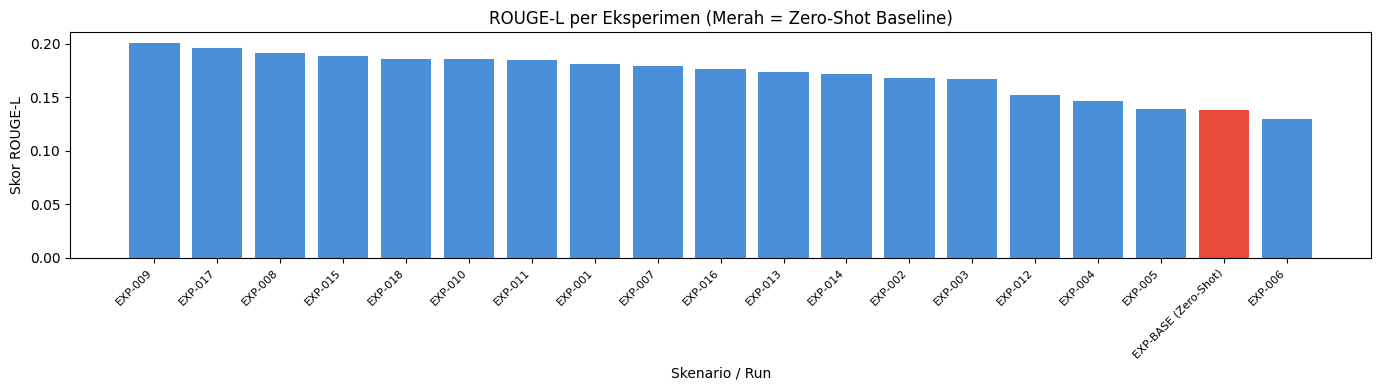

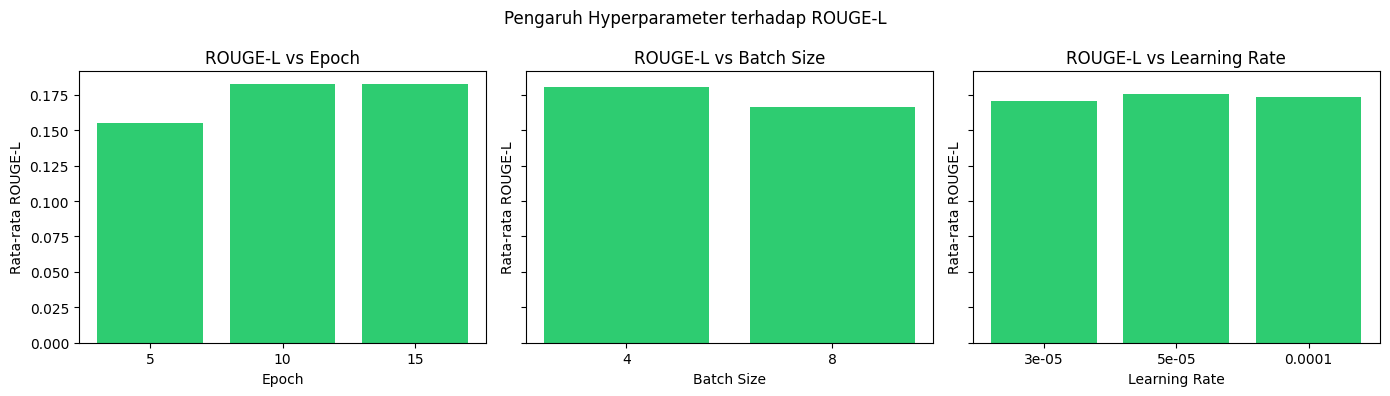

Grafik siap!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Urutkan berdasarkan ROUGE-L tertinggi
df_hasil_sorted = df_hasil.sort_values('rougeL', ascending=False).reset_index(drop=True)

# ==============================================================
# GRAFIK 1: KESELURUHAN ROUGE-L PER RUN
# ==============================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Warnai merah khusus untuk Zero-Shot model tanpa tuning
colors = ['#E74C3C' if 'Zero-Shot' in str(r) else '#4A90D9' for r in df_hasil_sorted['run']]
bars = ax.bar(df_hasil_sorted['run'], df_hasil_sorted['rougeL'], color=colors)

ax.set_title('ROUGE-L per Eksperimen (Merah = Zero-Shot Baseline)', fontsize=14, fontweight='bold')
ax.set_xlabel('Skenario / Run', fontsize=12)
ax.set_ylabel('Skor ROUGE-L', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), 
            ha='center', va='bottom', fontsize=9, rotation=90)

ax.set_ylim(0, max(df_hasil_sorted['rougeL']) * 1.3)

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'rouge_per_run.png', dpi=150, bbox_inches='tight')
plt.show()


# ==============================================================
# GRAFIK 2: PENGARUH HYPERPARAMETER
# ==============================================================
df_grid = df_hasil[df_hasil['run'] != 'EXP-BASE (Zero-Shot)']

fig2, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig2.suptitle('Pengaruh Hyperparameter terhadap Rata-Rata ROUGE-L', fontsize=14, fontweight='bold', y=1.05)

for ax, col, label in zip(axes, ['epoch', 'batch_size', 'learning_rate'], ['Epoch', 'Batch Size', 'Learning Rate']):
    g = df_grid.groupby(col)['rougeL'].mean().reset_index()
    bars_hp = ax.bar(g[col].astype(str), g['rougeL'], color='#2ECC71', edgecolor='black') # Tambah edgecolor biar tegas
    
    ax.set_title(f'ROUGE-L vs {label}', fontsize=12)
    ax.set_xlabel(label, fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('Rata-rata ROUGE-L', fontsize=11)
        
    for bar in bars_hp:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 4), 
                ha='center', va='bottom', fontsize=10)

axes[0].set_ylim(0, max(df_grid['rougeL']) * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'visualisasi_hyperparameter.png', dpi=150, bbox_inches='tight')
plt.show()

print('Grafik visualisasi sudah Siap!')

In [ ]:
import evaluate
from torch.utils.data import DataLoader
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

print("EVALUASI FINAL: MODEL TERBAIK SETELAH TUNING")

print(f"Memuat Model Terbaik dari: {BEST_DIR}...")
model_juara = AutoModelForSeq2SeqLM.from_pretrained(BEST_DIR).to(DEVICE)
tokenizer_juara = AutoTokenizer.from_pretrained(BEST_DIR)

model_juara.eval()
preds_final = []
# Ambil referensi dari kolom target yang baru
refs_final = df_test['target_summary_manual'].tolist()

test_ds.set_format('torch')
loader_final = DataLoader(test_ds, batch_size=2)

print("Sedang memproses evaluasi akhir...")
with torch.no_grad():
    for batch in loader_final:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        outputs = model_juara.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_OUT,
            no_repeat_ngram_size=3,
            num_beams=4,
            repetition_penalty=2.0,
            early_stopping=True,
        )
        decoded = tokenizer_juara.batch_decode(outputs, skip_special_tokens=True)
        preds_final.extend(decoded)

preds_final = [p.replace(PREFIX, '').strip() for p in preds_final]

rouge_final = evaluate.load('rouge')
pairs = [(p, r) for p, r in zip(preds_final, refs_final) if p.strip()]

if pairs:
    p_clean, r_clean = zip(*pairs)
    scores_final = rouge_final.compute(predictions=list(p_clean), references=list(r_clean), use_stemmer=False)

    print("\n=======================================================")
    print("SKOR ROUGE FINAL MODEL TERBAIK")
    print("=======================================================")
    print(f"  ROUGE-1 : {round(scores_final['rouge1'], 4)}")
    print(f"  ROUGE-2 : {round(scores_final['rouge2'], 4)}")
    print(f"  ROUGE-L : {round(scores_final['rougeL'], 4)}")

    print("\nBANDINGKAN HASIL TEKS:")
    # Sudah di-update istilahnya biar nggak bingung lagi!
    print(f"  [Ringkasan Manual Asli] : {r_clean[0][:200]}...")
    print(f"  [Prediksi Model IndoT5] : {p_clean[0][:200]}...")
else:
    print("Gagal menghitung ROUGE.")

del model_juara
if torch.cuda.is_available():
    torch.cuda.empty_cache()

🔥 UJI DIAGNOSTIK: MENGHAPUS PENALTI KEPENDEKAN TEKS PADA MODEL JUARA 🔥
Memuat Model Juara dari: /content/drive/MyDrive/models/indot5_finetuned...


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


⏳ Sedang memproses evaluasi dengan Jurus Teks Panjang...

🏆 SKOR ROUGE SETELAH JURUS 'HACK' (LENGTH PENALTY) 🏆
  ROUGE-1 : 0.3324
  ROUGE-2 : 0.1895
  ROUGE-L : 0.189

👀 COBA BANDINGKAN HASIL TEKSNYA:
  [Risalah Asli] : Hadirin kami persilakan untuk duduk kembali. Sidang Dewan yang kami hormati, Pada Rapat Paripurna hari ini, telah hadir peserta Parlemen Remaja Tahun 2025 di atas sana, tepuk tangannya. (TEPUK TANGAN ...
  [Prediksi Hack]: Dewan Perwakilan Rakyat periode tahun 2025-2025, yang kami hormati, atas nama Pimpinan DPR RI yang terhormat, yang telah menerima petikan Keputusan Presiden Republik Indonesia Nomor 103 Tahun Smeering...
